In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [119]:
std_data = pd.read_excel("std_data.xlsx", header=None)
std_data.head(10)



,0,1,2,3,4,5,6,7
0,"⚠️ DIRTY DATA - Mein Missing Values, Duplicat...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Student_ID,Student_Name,Study_Hours_Per_Day,Attendance_%,Previous_GPA,Assignments_Submitted,Sleep_Hours,Final_Marks
2,STU001,Fatima Noor,4.4,90.4,3.85,1.0,6.1,100
3,STU002,Ali Hassan,9.6,94.8,3.88,2.0,8.5,100
4,STU003,Hamza Sheikh,NaN,65.9,NaN,0.0,4.6,96.5
5,STU004,Zainab Hussain,6.4,55.5,2.43,0.0,NaN,83.8
6,STU005,Zainab Hussain,99,NaN,1.54,2.0,NaN,60.7
7,STU006,Bilal Ahmed,2.4,71.4,3.82,4.0,6.3,93.7
8,STU007,Fatima Noor,1.5,90.9,9.9,2.0,4.3,68
9,STU008,Amna Butt,8.8,93,3.92,0.0,4.6,100


In [120]:
std_data = pd.read_excel("std_data.xlsx", header=1)
std_data.head(10)

,Student_ID,Student_Name,Study_Hours_Per_Day,Attendance_%,Previous_GPA,Assignments_Submitted,Sleep_Hours,Final_Marks
0,STU001,Fatima Noor,4.4,90.4,3.85,1.0,6.1,100.0
1,STU002,Ali Hassan,9.6,94.8,3.88,2.0,8.5,100.0
2,STU003,Hamza Sheikh,NaN,65.9,NaN,0.0,4.6,96.5
3,STU004,Zainab Hussain,6.4,55.5,2.43,0.0,NaN,83.8
4,STU005,Zainab Hussain,99.0,NaN,1.54,2.0,NaN,60.7
5,STU006,Bilal Ahmed,2.4,71.4,3.82,4.0,6.3,93.7
6,STU007,Fatima Noor,1.5,90.9,9.90,2.0,4.3,68.0
7,STU008,Amna Butt,8.8,93.0,3.92,0.0,4.6,100.0
8,STU009,ahmed raza,NaN,50.3,3.91,0.0,4.6,88.6
9,STU010,Faisal Nawaz,7.4,75.5,3.63,7.0,7.2,100.0


In [121]:
# Understanding dataset
std_data.info()
std_data.describe()
std_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             125 non-null    object 
 1   Student_Name           125 non-null    object 
 2   Study_Hours_Per_Day    114 non-null    float64
 3   Attendance_%           114 non-null    float64
 4   Previous_GPA           115 non-null    float64
 5   Assignments_Submitted  125 non-null    object 
 6   Sleep_Hours            115 non-null    object 
 7   Final_Marks            125 non-null    float64
dtypes: float64(4), object(4)
memory usage: 7.9+ KB


Student_ID                0
Student_Name              0
Study_Hours_Per_Day      11
Attendance_%             11
Previous_GPA             10
Assignments_Submitted     0
Sleep_Hours              10
Final_Marks               0
dtype: int64

In [122]:
print(std_data.columns)

Index(['Student_ID', 'Student_Name', 'Study_Hours_Per_Day', 'Attendance_%',
       'Previous_GPA', 'Assignments_Submitted', 'Sleep_Hours', 'Final_Marks'],
      dtype='object')


In [123]:
std_data = pd.read_excel("std_data.xlsx", header=1)

In [124]:
print(std_data.columns)
std_data.head()

Index(['Student_ID', 'Student_Name', 'Study_Hours_Per_Day', 'Attendance_%',
       'Previous_GPA', 'Assignments_Submitted', 'Sleep_Hours', 'Final_Marks'],
      dtype='object')


,Student_ID,Student_Name,Study_Hours_Per_Day,Attendance_%,Previous_GPA,Assignments_Submitted,Sleep_Hours,Final_Marks
0,STU001,Fatima Noor,4.4,90.4,3.85,1.0,6.1,100.0
1,STU002,Ali Hassan,9.6,94.8,3.88,2.0,8.5,100.0
2,STU003,Hamza Sheikh,NaN,65.9,NaN,0.0,4.6,96.5
3,STU004,Zainab Hussain,6.4,55.5,2.43,0.0,NaN,83.8
4,STU005,Zainab Hussain,99.0,NaN,1.54,2.0,NaN,60.7


In [125]:
print(std_data.columns)


Index(['Student_ID', 'Student_Name', 'Study_Hours_Per_Day', 'Attendance_%',
       'Previous_GPA', 'Assignments_Submitted', 'Sleep_Hours', 'Final_Marks'],
      dtype='object')


In [126]:
std_data = std_data.drop_duplicates(subset=['Student_ID'])


In [127]:
std_data = std_data.drop(["Student_ID", "Student_Name"], axis=1, errors="ignore")

In [128]:
std_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours_Per_Day    111 non-null    float64
 1   Attendance_%           111 non-null    float64
 2   Previous_GPA           111 non-null    float64
 3   Assignments_Submitted  120 non-null    object 
 4   Sleep_Hours            111 non-null    object 
 5   Final_Marks            120 non-null    float64
dtypes: float64(4), object(2)
memory usage: 6.6+ KB


In [129]:
# Step 1: Clean column names (strip spaces)
std_data.columns = std_data.columns.str.strip()

# Step 2: Convert numeric columns properly
numeric_cols = ['Study_Hours_Per_Day', 'Attendance_%', 'Previous_GPA', 
                'Assignments_Submitted', 'Sleep_Hours', 'Final_Marks']

for col in numeric_cols:
    std_data[col] = pd.to_numeric(std_data[col], errors='coerce')

# Step 3: Remove outliers (extreme values)
std_data = std_data[(std_data['Study_Hours_Per_Day'] <= 16) & (std_data['Study_Hours_Per_Day'] >= 0)]
std_data = std_data[(std_data['Attendance_%'] <= 100) & (std_data['Attendance_%'] >= 0)]
std_data = std_data[(std_data['Sleep_Hours'] <= 12) & (std_data['Sleep_Hours'] >= 0)]
std_data = std_data[(std_data['Final_Marks'] <= 100) & (std_data['Final_Marks'] >= 0)]

# Step 4: Fill missing with median
std_data[numeric_cols] = std_data[numeric_cols].fillna(std_data[numeric_cols].median())

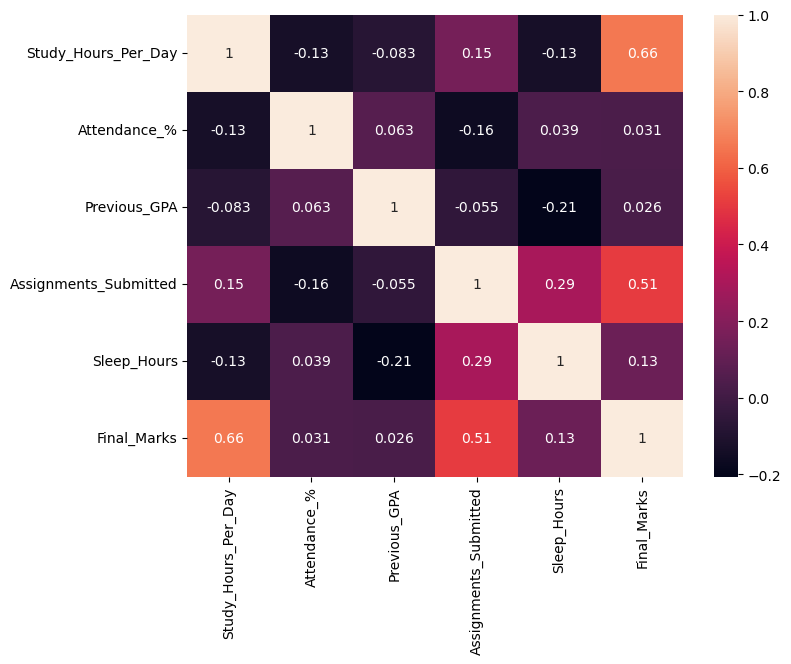

In [130]:
plt.figure(figsize=(8,6))
sns.heatmap(std_data.corr(), annot=True)
plt.show()

In [131]:
X = std_data.drop("Final_Marks", axis=1)
y = std_data["Final_Marks"]

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [133]:

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

In [134]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [135]:
model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

In [136]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Study_Hours_Per_Day', 'Attendance_%', 'Previous_GPA',
       'Assignments_Submitted', 'Sleep_Hours'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('regressor', LinearRegression())])

In [137]:
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.355716796463339


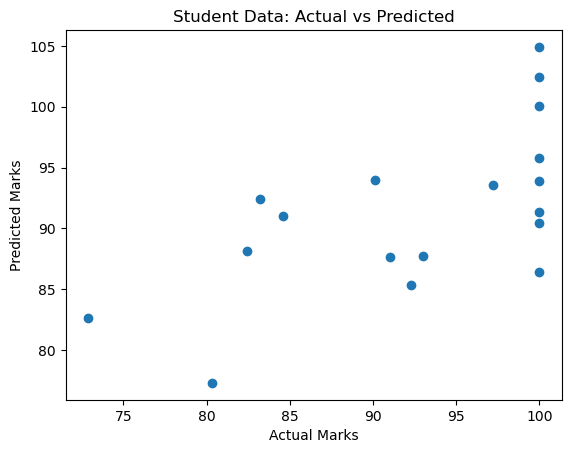

In [138]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Student Data: Actual vs Predicted")
plt.show()

In [139]:
# METHOD 1: Polynomial Features (Degree 2)
# ============================================
print("=" * 50)
print("METHOD 1: Polynomial Features (Degree 2)")
print("=" * 50)

# Create pipeline with scaling + polynomial features + regression
poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print(f"R² Score: {r2_poly:.4f}")
print(f"MSE: {mse_poly:.2f}")
print(f"Improvement from {0.3557:.4f} to {r2_poly:.4f} = +{(r2_poly - 0.3557)*100:.1f}%")


METHOD 1: Polynomial Features (Degree 2)
R² Score: 0.7689
MSE: 16.23
Improvement from 0.3557 to 0.7689 = +41.3%


In [140]:


joblib.dump(model, 'student_performance_model.pkl')
print(" Model saved!")

 Model saved!
